In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Pokemon.csv")
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 75.9 KB


df.shape

Numéricas: HP, Attack, Defense, Sp.Atk, Sp.Def, Speed, Total
Categóricas: Type 1, Type 2 ("386 Pokémon son mono-tipo, por eso Type 2 tiene 386 NaN que representan ausencia de segundo tipo, no datos faltantes"), Generation
Booleana: Legendary
Identificadores: #, Name

In [19]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [20]:
df.describe(include="str")

,Name,Type 1,Type 2
count,800,800,414
unique,800,18,18
top,Bulbasaur,Water,Flying
freq,1,112,97


In [21]:
df.corr(numeric_only=True)

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,1.000000,0.119813,0.097614,0.102298,0.094786,0.088759,0.085817,0.010733,0.982516,0.153396
Total,0.119813,1.000000,0.618748,0.736211,0.612787,0.747250,0.717609,0.575943,0.048384,0.501758
HP,0.097614,0.618748,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.058683,0.273620
Attack,0.102298,0.736211,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.051451,0.345408
Defense,0.094786,0.612787,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.042419,0.246377
Sp. Atk,0.088759,0.747250,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.036437,0.448907
Sp. Def,0.085817,0.717609,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.028486,0.363937
Speed,0.010733,0.575943,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,-0.023121,0.326715
Generation,0.982516,0.048384,0.058683,0.051451,0.042419,0.036437,0.028486,-0.023121,1.000000,0.079794
Legendary,0.153396,0.501758,0.273620,0.345408,0.246377,0.448907,0.363937,0.326715,0.079794,1.000000


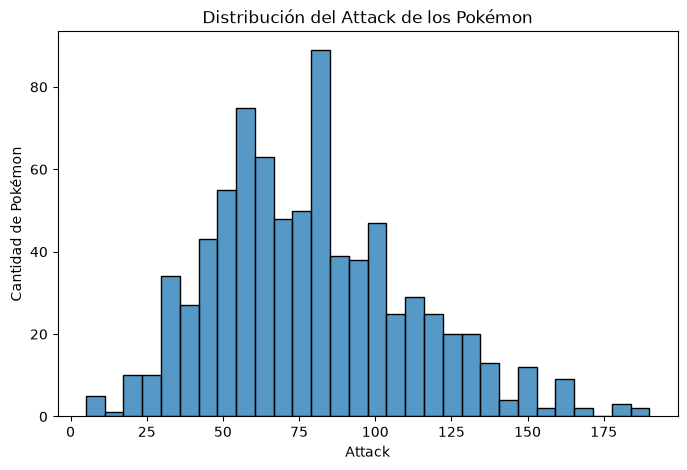

In [22]:
plt.figure(figsize=(8, 5))          # tamaño del gráfico (ancho, alto en pulgadas)
sns.histplot(data=df, x="Attack", bins=30)   # el histograma de la columna Attack
plt.title("Distribución del Attack de los Pokémon")   # título
plt.xlabel("Attack")                # etiqueta del eje X
plt.ylabel("Cantidad de Pokémon")   # etiqueta del eje Y
plt.show()                          # mostrar

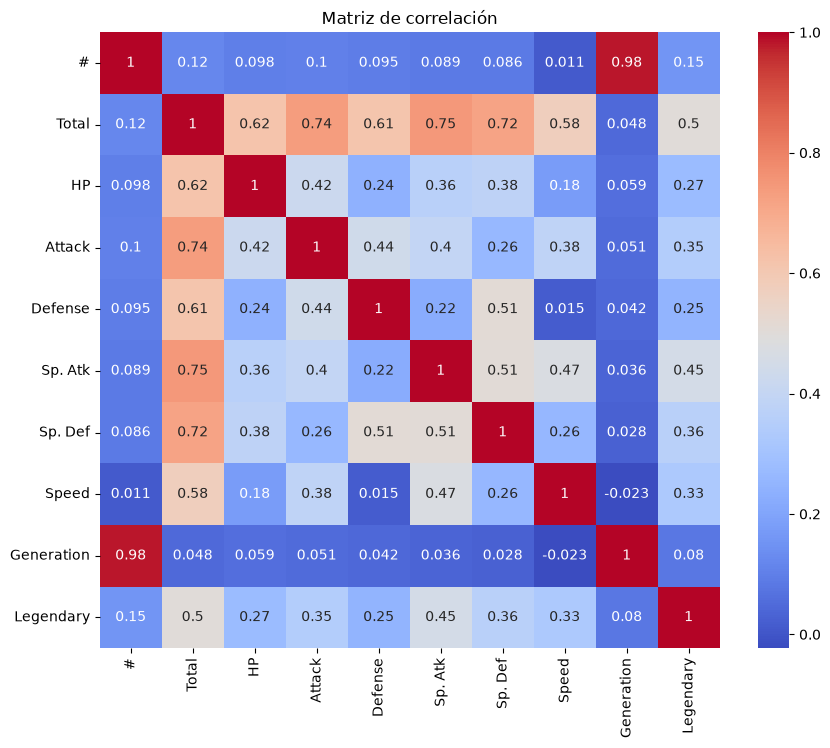

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

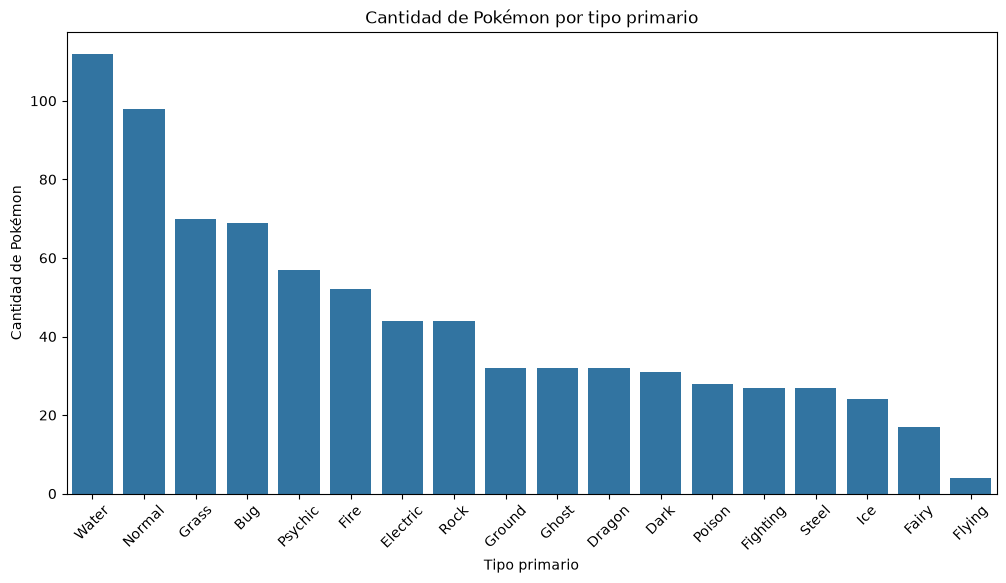

In [24]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Type 1", order=df["Type 1"].value_counts().index)
plt.title("Cantidad de Pokémon por tipo primario")
plt.xlabel("Tipo primario")
plt.ylabel("Cantidad de Pokémon")
plt.xticks(rotation=45) # Se me superponian los nombres, con esto ajusto a 45
plt.show()

Conclusión:
* El Attack tiene distribución sesgada a la derecha (media > mediana), con la mayoría entre 50-85 y unos pocos Pokémon de ataque muy alto.
* Total correlaciona fuerte con todas las stats porque es su suma; entre stats independientes la correlación es baja (ej. Speed y Defense ~0).
Water es el tipo primario más frecuente (112), Flying el más raro como primario.
"#" y Generation casi perfectamente correlacionados → # es un identificador ligado al orden de generaciones.
386 Pokémon son mono-tipo (Type 2 nulo).

---
# 1. Características generales del dataset

Antes de analizar relaciones entre variables conviene responder: *¿qué tan grande es?, ¿está sucio?, ¿hay algo raro en cómo está construido?*

In [25]:
print("Filas y columnas:", df.shape)
print("Memoria:", round(df.memory_usage(deep=True).sum() / 1024, 1), "KB")

Filas y columnas: (800, 13)
Memoria: 179.0 KB


Dataset **chico**: 800 filas x 13 columnas, ~179 KB. Entra entero en memoria (no hace falta muestreo ni herramientas de big data), pero 800 filas son pocas para modelos complejos.

In [26]:
print("Nulos por columna:")
print(df.isna().sum())
print("\nFilas duplicadas:", df.duplicated().sum())
print("Nombres duplicados:", df["Name"].duplicated().sum())

Nulos por columna:
#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

Filas duplicadas: 0
Nombres duplicados: 0


**Curiosidad 1 - los nulos de `Type 2` no son datos faltantes.**

Los 386 NaN de `Type 2` representan Pokémon **mono-tipo**: la ausencia de un segundo tipo *es* la información, no un error de carga. Es la diferencia entre *missing* y *not applicable*.

Consecuencia práctica: un `dropna()` borraría el 48% del dataset sin motivo. Lo correcto es imputar con una categoría explícita `"None"`.

In [27]:
df["Type 2"] = df["Type 2"].fillna("None")
print(df["Type 2"].value_counts().head())
print("\nNulos restantes en el dataset:", df.isna().sum().sum())

Type 2
None       386
Flying      97
Ground      35
Poison      34
Psychic     33
Name: count, dtype: int64

Nulos restantes en el dataset: 0


In [28]:
print("Filas:", len(df), "| Valores únicos de '#':", df["#"].nunique())
df[df["#"] == 6][["#", "Name", "Type 1", "Type 2", "Total"]]

Filas: 800 | Valores únicos de '#': 721


,#,Name,Type 1,Type 2,Total
6,6,Charizard,Fire,Flying,534
7,6,CharizardMega Charizard X,Fire,Dragon,634
8,6,CharizardMega Charizard Y,Fire,Flying,634


In [29]:
megas = df[df["Name"].str.contains("Mega")]
print("Formas Mega en el dataset:", len(megas))
print("Total promedio Mega:", round(megas["Total"].mean(), 1))
print("Total promedio resto:", round(df[~df["Name"].str.contains("Mega")]["Total"].mean(), 1))

Formas Mega en el dataset: 49
Total promedio Mega: 615.7
Total promedio resto: 423.3


**Curiosidad 2 - `#` no es una clave primaria.**

800 filas pero solo 721 valores distintos de `#`. Las **49 formas Mega** comparten el número de Pokédex con su forma base (ej: Charizard, Mega Charizard X y Mega Charizard Y son todos `#6`).

Dos consecuencias:
- `#` no sirve como identificador único.
- Las Megas son **casi-duplicados con stats inflados** (Total promedio ~630 vs ~424 del resto). Son las principales responsables de los outliers por arriba.

In [30]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
print("Filas donde Total != suma de las 6 stats:", (df["Total"] != df[stats].sum(axis=1)).sum())

Filas donde Total != suma de las 6 stats: 0


**Curiosidad 3 - `Total` es una columna derivada.**

En las 800 filas se cumple exactamente `Total = HP + Attack + Defense + Sp. Atk + Sp. Def + Speed`.

Por eso `Total` correlaciona 0.6-0.75 con todas las stats en el heatmap: **no es un hallazgo, es aritmética**. Para modelar, usar `Total` junto a las 6 stats genera multicolinealidad perfecta, y predecir una stat teniendo `Total` es *data leakage*.

In [31]:
print("Pokémon por generación:")
print(df["Generation"].value_counts().sort_index())
print("\nDistribución de Legendary:")
print(df["Legendary"].value_counts())
print("Proporción de legendarios: %.2f%%" % (100 * df["Legendary"].mean()))

Pokémon por generación:
Generation
1    166
2    106
3    160
4    121
5    165
6     82
Name: count, dtype: int64

Distribución de Legendary:
Legendary
False    735
True      65
Name: count, dtype: int64
Proporción de legendarios: 8.12%


**Desbalance en las categóricas:**

- `Generation`: de 166 (gen 1) a 82 (gen 6) - la gen 6 está incompleta porque el dataset se cortó a mitad de esa generación.
- `Legendary`: 735 / 65 -> solo **8.12%** son legendarios. Clase fuertemente desbalanceada: un clasificador que responda siempre "no legendario" acierta 91.9%. Por eso el *accuracy* sería una métrica engañosa acá.
- `Type 1`: 18 categorías, de Water (112) a Flying (4) - alta cardinalidad con categorías muy raras.

# 2. Detección de Outliers

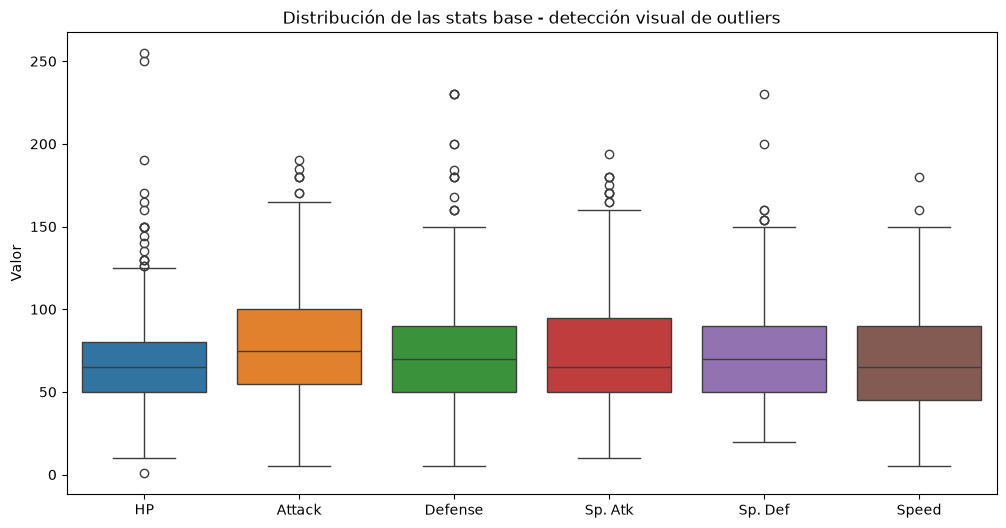

In [32]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

plt.figure(figsize=(12,6))
sns.boxplot(data=df[stats])
plt.title("Distribución de las stats base - detección visual de outliers")
plt.ylabel("Valor")
plt.show()

In [34]:
def contar_outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    mask = (df[col] < lim_inf) | (df[col] > lim_sup)
    return {
        "stat": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lim_inf": round(lim_inf, 1),
        "lim_sup": round(lim_sup, 1),
        "n_outliers": int(mask.sum()),
        "%": round(100 * mask.mean(), 2),
    }

resumen = pd.DataFrame([contar_outliers(c) for c in stats + ["Total"]])
resumen

    

,stat,Q1,Q3,IQR,lim_inf,lim_sup,n_outliers,%
0,HP,50.00,80.0,30.00,5.0,125.0,19,2.38
1,Attack,55.00,100.0,45.00,-12.5,167.5,7,0.88
2,Defense,50.00,90.0,40.00,-10.0,150.0,13,1.62
3,Sp. Atk,49.75,95.0,45.25,-18.1,162.9,10,1.25
4,Sp. Def,50.00,90.0,40.00,-10.0,150.0,7,0.88
5,Speed,45.00,90.0,45.00,-22.5,157.5,2,0.25
6,Total,330.00,515.0,185.00,52.5,792.5,0,0.00


## 2.3 - Identificación: ¿quiénes son los outliers?

In [37]:
for col in stats:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    print(f"\n--- {col}: {len(out)} outliers ---")
    print(out.nlargest(3, col)[["Name", col, "Total", "Legendary"]].to_string(index=False))
    bajos = out[out[col] < lim_inf]
    if len(bajos) > 0:
        print("POR ABAJO:", bajos[["Name", col]].to_string(index=False))


--- HP: 19 outliers ---
     Name  HP  Total  Legendary
  Blissey 255    540      False
  Chansey 250    450      False
Wobbuffet 190    405      False
POR ABAJO:     Name  HP
Shedinja   1

--- Attack: 7 outliers ---
                   Name  Attack  Total  Legendary
    MewtwoMega Mewtwo X     190    780       True
HeracrossMega Heracross     185    600      False
  GroudonPrimal Groudon     180    770       True

--- Defense: 13 outliers ---
               Name  Defense  Total  Legendary
SteelixMega Steelix      230    610      False
            Shuckle      230    505      False
  AggronMega Aggron      230    630      False

--- Sp. Atk: 10 outliers ---
                 Name  Sp. Atk  Total  Legendary
  MewtwoMega Mewtwo Y      194    780       True
  KyogrePrimal Kyogre      180    770       True
RayquazaMega Rayquaza      180    780       True

--- Sp. Def: 7 outliers ---
               Name  Sp. Def  Total  Legendary
            Shuckle      230    505      False
             Re

In [39]:
mask_any = pd.Series(False, index=df.index)

for col in stats:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    mask_any |= (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)

out = df[mask_any]

print("Pokémon con al menos un outlier:", len(out), f"({100 * len(out) / len(df):.1f}%)")
print("  de los cuales, legendarios:", int(out["Legendary"].sum()))
print("  de los cuales, formas Mega:", int(out["Name"].str.contains("Mega").sum()))
print()
print("Legendarios DENTRO de los outliers: %.1f%%" % (100 * out["Legendary"].mean()))
print("Legendarios en TODO el dataset:     %.1f%%" % (100 * df["Legendary"].mean()))


Pokémon con al menos un outlier: 52 (6.5%)
  de los cuales, legendarios: 19
  de los cuales, formas Mega: 12

Legendarios DENTRO de los outliers: 36.5%
Legendarios en TODO el dataset:     8.1%


In [40]:
df[stats + ["Total"]].skew().round(3)


HP         1.568
Attack     0.552
Defense    1.156
Sp. Atk    0.745
Sp. Def    0.854
Speed      0.358
Total      0.153
dtype: float64

## 2.5 — Conclusiones sobre outliers

**Cuántos:** 52 Pokémon (6.5%) son outliers en al menos una stat. Ninguna stat
individual supera el 2.4%, lo que descarta errores sistemáticos de carga.

**Quiénes:** 19 legendarios y 12 formas Mega — el 60% de los outliers. Los
legendarios están **4.5x sobrerrepresentados**: son el 36.5% de los outliers
pero solo el 8.1% del dataset.

**Naturaleza:** ninguno es un error. Validado contra el dominio:
- Shedinja (HP=1) es el único outlier inferior y responde a un diseño
  deliberado del juego (habilidad *Wonder Guard*), no a un dato mal cargado.
- Megas y legendarios son formas oficialmente más poderosas.

**Decisión: NO se eliminan.**
1. No son errores, son casos extremos legítimos.
2. Eliminarlos borraría 19 de 65 legendarios (29% de la clase minoritaria)
   en un dataset ya desbalanceado.
3. El outlier es la señal, no el ruido.

**Asimetría:** HP (1.57) y Defense (1.16) son las más asimétricas; Speed (0.36)
la más simétrica. `Total` tiene skew 0.15 — casi simétrica pese a que sus 6
componentes son asimétricas positivas. Confirma el balance por presupuesto.

**Técnicas recomendadas si se modelara:**
- `RobustScaler` (centra en la mediana, escala por IQR) en lugar de
  `StandardScaler`, para que los extremos no distorsionen el escalado.
- Modelos basados en árboles, insensibles a outliers y a transformaciones
  monótonas.
- Marcar las formas Mega con una columna `is_mega` en vez de descartarlas:
  convierte la contaminación en información.


---
# 3. Desafíos a priori y técnicas aplicables


In [45]:
combo = df["Type 1"] + "/" + df["Type 2"]

print("Tipos primarios únicos:", df["Type 1"].nunique())
print("Tipos secundarios únicos (incluyendo 'None'):", df["Type 2"].nunique())
print("Combinaciones posibles:", df["Type 1"].nunique() * df["Type 2"].nunique())
print("Combinaciones realmente observadas:", combo.nunique())

vc = combo.value_counts()
print("\nCombinaciones con 1 solo Pokémon:", (vc == 1).sum())
print("Combinaciones con 3 o menos:", (vc <= 3).sum())

print("\nTipos primarios con menos de 20 casos:")
t1 = df["Type 1"].value_counts()
print(t1[t1 < 20].to_string())


Tipos primarios únicos: 18
Tipos secundarios únicos (incluyendo 'None'): 19
Combinaciones posibles: 342
Combinaciones realmente observadas: 154

Combinaciones con 1 solo Pokémon: 39
Combinaciones con 3 o menos: 107

Tipos primarios con menos de 20 casos:
Type 1
Fairy     17
Flying     4


In [46]:
formas = df["#"].value_counts()

print("Pokémon (por #) con más de una fila:", (formas > 1).sum())
print("Filas que son formas alternativas:", len(df) - df["#"].nunique())
print("\nEl # con más formas:")
df[df["#"] == formas.idxmax()][["#", "Name", "Type 1", "Total", "Legendary"]]


Pokémon (por #) con más de una fila: 65
Filas que son formas alternativas: 79

El # con más formas:


,#,Name,Type 1,Total,Legendary
531,479,Rotom,Electric,440,False
532,479,RotomHeat Rotom,Electric,520,False
533,479,RotomWash Rotom,Electric,520,False
534,479,RotomFrost Rotom,Electric,520,False
535,479,RotomFan Rotom,Electric,520,False
536,479,RotomMow Rotom,Electric,520,False


## 3.3 — Síntesis de desafíos y técnicas

| # | Desafío | Evidencia | Técnica aplicable |
|---|---|---|---|
| 1 | **Multicolinealidad y variable derivada** | `Total` = suma exacta de las 6 stats (0 excepciones). `#` vs `Generation` r = 0.98 | Usar `Total` **o** las 6 stats, nunca ambas. Descartar `#` (identificador, no predictor). |
| 2 | **Alta cardinalidad categórica** | 154 combinaciones de tipo observadas; 39 con un solo Pokémon; Flying tiene 4 casos como primario | *Multi-hot* de 18 columnas en vez de one-hot de Type1+Type2 (el orden es arbitrario). Agrupar categorías raras en "Otros". |
| 3 | **Desbalance de clase** | Legendary: 8.12% (65 de 800) | `stratify` en el split, `class_weight="balanced"`, y métricas F1 / recall / AUC en lugar de *accuracy*. |
| 4 | **Casi-duplicados y fuga de datos** | 79 filas son formas alternativas del mismo `#` (49 Megas) | Split agrupado por `#` (`GroupShuffleSplit`) para que las formas de un Pokémon no se repartan entre train y test. |
| 5 | **Tamaño reducido** | 800 filas → un test 80/20 deja solo ~13 legendarios | Validación cruzada estratificada en lugar de un único *holdout*; las métricas de un solo split serían muy inestables. |

**Sobre el escalado:** las 6 stats comparten un rango comparable (todas entre 1 y 255),
así que escalarlas entre sí no es crítico. Sí lo sería al combinarlas con `Total`
(180-780). Si se escalara, conviene `RobustScaler` (mediana + IQR) antes que
`StandardScaler`, dado que la media y el desvío están afectados por los outliers.

**Nota transversal:** ninguno de estos desafíos es un problema de *calidad* de los
datos — el dataset no tiene errores de carga, duplicados exactos ni nulos reales.
Son desafíos de **estructura**: cómo está construido el dataset condiciona cómo
hay que modelarlo.
